# *Tech Challenge - Fase 4*

In [10]:
#Base de dados: https://br.investing.com/commodities/brent-oil-historical-data
#Dados de 2019 até 2023

In [42]:
import pandas as pd
import pandas.io.sql as sqlio
import psycopg2 as ps
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [12]:
#chamando o banco de dados
knime = ps.connect(dbname = "FOB", user = "postgres", password = "admin", host = "localhost", port = "5432") 

In [13]:
#chamando a tabela
sql = """
SELECT * FROM fob.preco_petroleo
"""

In [14]:
#criando a variavel com a tabela que está no banco
dados = sqlio.read_sql_query(sql, knime)

C:\Users\aila.endo\AppData\Local\Temp\ipykernel_11908\1038648.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dados = sqlio.read_sql_query(sql, knime)


In [15]:
dados.head()

,data_coletado,preco,abertura,maxima,minima,volume,variacao
0,29.12.2023,"76,91","77,26","77,81","76,60","83,30K","-0,31%"
1,28.12.2023,"77,15","79,55","79,87","77,10","282,23K","-3,00%"
2,27.12.2023,"79,54","80,57","81,02","79,23","282,66K","-1,62%"
3,26.12.2023,"80,85","78,74","81,45","78,37","184,69K","2,60%"
4,22.12.2023,"78,80","79,13","80,10","78,64","227,18K","-0,45%"


In [16]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   data_coletado  1552 non-null   object
 1   preco          1552 non-null   object
 2   abertura       1552 non-null   object
 3   maxima         1552 non-null   object
 4   minima         1552 non-null   object
 5   volume         1552 non-null   object
 6   variacao       1552 non-null   object
dtypes: object(7)
memory usage: 85.0+ KB


In [17]:
#transformando em tipo date
dados["data_coletado"] = pd.to_datetime(dados["data_coletado"], format= "%d.%m.%Y")

In [18]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype        
---  ------         --------------  -----        
 0   data_coletado  1552 non-null   datetime64[s]
 1   preco          1552 non-null   object       
 2   abertura       1552 non-null   object       
 3   maxima         1552 non-null   object       
 4   minima         1552 non-null   object       
 5   volume         1552 non-null   object       
 6   variacao       1552 non-null   object       
dtypes: datetime64[s](1), object(6)
memory usage: 85.0+ KB


In [19]:
dados_usaveis = dados[["data_coletado", "preco", "volume"]]

In [20]:
dados_usaveis

,data_coletado,preco,volume
0,2023-12-29,"76,91","83,30K"
1,2023-12-28,"77,15","282,23K"
2,2023-12-27,"79,54","282,66K"
3,2023-12-26,"80,85","184,69K"
4,2023-12-22,"78,80","227,18K"
...,...,...,...
1547,2019-02-03,"62,10","1,28M"
1548,2019-01-27,"62,75","735,10K"
1549,2019-01-20,"61,64","1,22M"
1550,2019-01-13,"62,70","1,38M"


In [ ]:
def converter_volume(valor):
    #removendo os espaços em branco
    valor = valor.strip()
    
    if "K" in valor:
        #removendo o 'K' e substituindo a vírgula por ponto
        valor = valor.replace("K", "").replace(",", ".")
        #convertendo para float e multiplicando por 1000
        return float(valor) * 1_000
    elif "M" in valor:
        #removendo o 'M' e substituindo a vírgula por ponto
        valor = valor.replace("M", "").replace(",", ".")
        #convertendo para float e multiplicando por 1.000.000
        return float(valor) * 1_000_000
    else:
        #se não tiver 'K' ou 'M', converter diretamente para float
        return float(valor)

#aplicando a função à coluna "volume"
dados_usaveis["volume"] = dados_usaveis["volume"].apply(converter_volume).astype(int)

print(dados_usaveis["volume"])

0         83300
1        282230
2        282660
3        184690
4        227180
         ...   
1547    1280000
1548     735100
1549    1220000
1550    1380000
1551    1510000
Name: volume, Length: 1552, dtype: int32


In [22]:
dados_usaveis

,data_coletado,preco,volume
0,2023-12-29,"76,91",83300
1,2023-12-28,"77,15",282230
2,2023-12-27,"79,54",282660
3,2023-12-26,"80,85",184690
4,2023-12-22,"78,80",227180
...,...,...,...
1547,2019-02-03,"62,10",1280000
1548,2019-01-27,"62,75",735100
1549,2019-01-20,"61,64",1220000
1550,2019-01-13,"62,70",1380000


In [23]:
#transformando a coluna em index
dados_usaveis = dados_usaveis.set_index("data_coletado")

In [24]:
dados_usaveis.head()

,preco,volume
data_coletado,,
2023-12-29,"76,91",83300
2023-12-28,"77,15",282230
2023-12-27,"79,54",282660
2023-12-26,"80,85",184690
2023-12-22,"78,80",227180


In [25]:
dados_usaveis.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1552 entries, 2023-12-29 to 2019-01-06
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   preco   1552 non-null   object
 1   volume  1552 non-null   int32 
dtypes: int32(1), object(1)
memory usage: 30.3+ KB


In [26]:
#baixando a tabela editada
#dados_usaveis.to_excel('dados_petroleo.xlsx', index=True)

In [ ]:
#substituindo a virgula por ponto
dados_usaveis["preco"] = dados_usaveis["preco"].str.replace(",", ".").astype(float)

In [ ]:
#convertendo para dados numericos
dados_usaveis["preco"] = pd.to_numeric(dados_usaveis["preco"])

In [ ]:
#media de cada mês
preco_por_mes = dados_usaveis["preco"].resample("MS").mean()

In [36]:
preco_por_mes

data_coletado
2019-01-01     60.489231
2019-02-01     64.596667
2019-03-01     66.986154
2019-04-01     71.120000
2019-05-01     68.986296
2019-06-01     62.342400
2019-07-01     63.857037
2019-08-01     58.951538
2019-09-01     61.116538
2019-10-01     59.404815
2019-11-01     61.762800
2019-12-01     64.450769
2020-01-01     62.605000
2020-02-01     55.242083
2020-03-01     35.236667
2020-04-01     29.540000
2020-05-01     33.794615
2020-06-01     40.956154
2020-07-01     43.461111
2020-08-01     45.370000
2020-09-01     42.307692
2020-10-01     41.908846
2020-11-01     44.358077
2020-12-01     50.393846
2021-01-01     55.350400
2021-02-01     62.116667
2021-03-01     65.341481
2021-04-01     64.900800
2021-05-01     68.143462
2021-06-01     72.981538
2021-07-01     73.601538
2021-08-01     69.888889
2021-09-01     74.420385
2021-10-01     83.060769
2021-11-01     79.087308
2021-12-01     74.734815
2022-01-01     85.112692
2022-02-01     92.989167
2022-03-01    108.938519
2022-04-01 

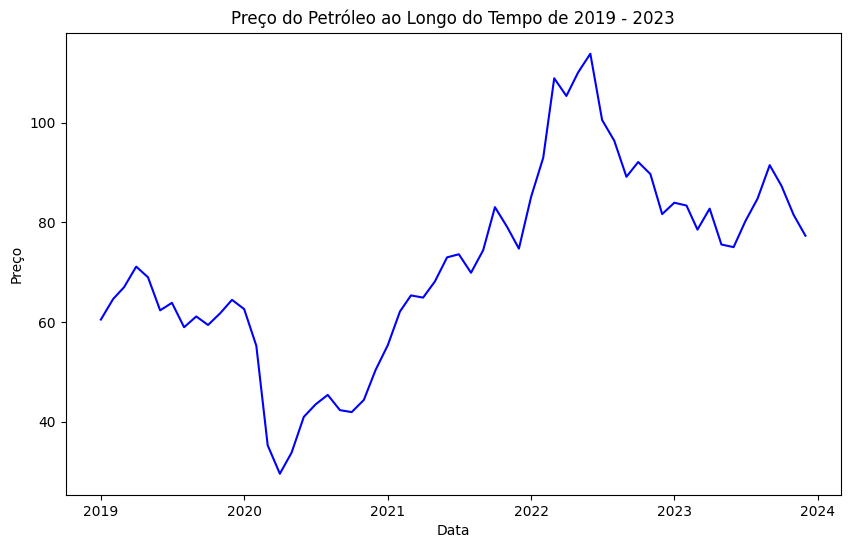

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(preco_por_mes, color="blue")
plt.title("Preço do Petróleo ao Longo do Tempo de 2019 - 2023")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.show()

In [ ]:
#teste e treino
train_size = int(len(preco_por_mes) * 0.8)
train, test = preco_por_mes[:train_size], preco_por_mes[train_size:]

In [ ]:
#definindo os parâmetros do modelo ARIMA (p, d, q)
p, d, q = 5, 1, 0

#treinando o modelo
model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

#visualizando o resumo do modelo
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  preco   No. Observations:                   48
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -149.111
Date:                Thu, 14 Nov 2024   AIC                            304.222
Time:                        16:36:47   BIC                            309.707
Sample:                    01-01-2019   HQIC                           306.277
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3301      0.187      1.766      0.077      -0.036       0.696
ma.L1         -0.9998     15.742     -0.064      0.949     -31.853      29.853
sigma2        35.7340    563.705      0.063      0.9

Erro Quadrático Médio (RMSE): 4.82


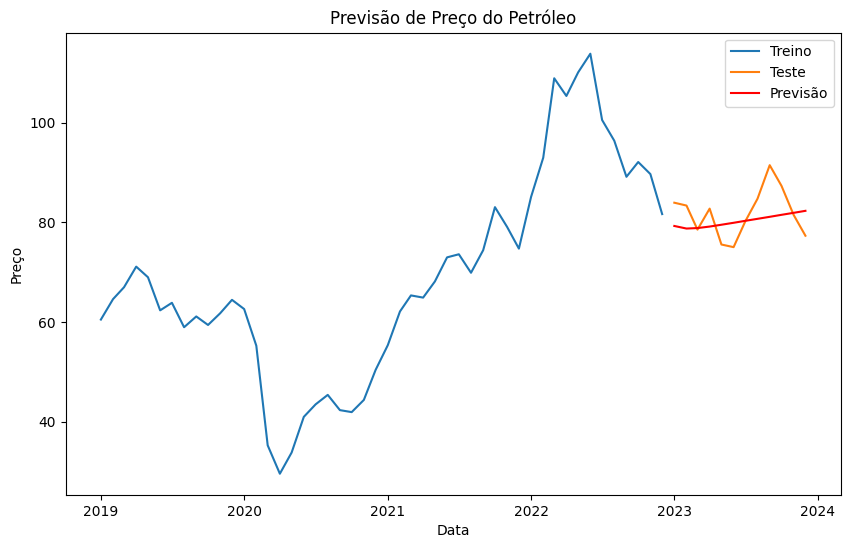

In [50]:
#fazer previsões
forecast = model_fit.forecast(steps=len(test))
forecast_index = test.index

#calculando o erro (RMSE)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"Erro Quadrático Médio (RMSE): {rmse:.2f}")

#visualizando as previsões e os valores
plt.figure(figsize=(10, 6))
plt.plot(train.index, train, label="Treino")
plt.plot(test.index, test, label="Teste")
plt.plot(forecast_index, forecast, label="Previsão", color="red")
plt.title("Previsão de Preço do Petróleo")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.show()